# 🏔️ Alpine Signal Radar — Opportunity Dashboard

A **scenario-driven** retail opportunity radar. Pitched on Swiss outdoor, but the engine is generic — every retailer/community/market specific lives in `config/scenarios/*.yaml`, not in code.

**Pipeline:** signals → normalize → dedup → score → transfer (CH/DACH) → action.  
Run `python -m src.collect_offline` then `python -m src.pipeline` to refresh the artifacts this notebook reads. *(Claude enrichment is used if `ANTHROPIC_API_KEY` is set; otherwise a deterministic fallback runs.)*

In [1]:
# Setup — switch SCENARIO to render any profile
import os, sys
# run from repo root so `src` imports and relative artifact paths resolve
while not os.path.isdir('src'):
    parent = os.path.dirname(os.getcwd())
    if parent == os.getcwd():
        break
    os.chdir(parent)
sys.path.insert(0, os.getcwd())

import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from src import report

SCENARIO = 'swiss_outdoor'
opps, summary = report.load_results(SCENARIO)
scn = report.get_scenario(SCENARIO)
ranked = sorted(report.live(opps), key=lambda o: o['final_score'], reverse=True)
f"{len(opps)} opportunities — {len(ranked)} surfaced, {len(report.dead(opps))} discarded"

'13 opportunities — 10 surfaced, 3 discarded'

## 1. Executive summary

In [2]:
display(Markdown(summary))

# Swiss Outdoor Retail — Opportunity Summary

The strongest near-term plays are integrated filter-flask hydration and challenger trail-running brands, both backed by genuine race/community legitimacy and an open CH transfer window—the latter sharpened by UTMB 2026's proximity to Switzerland. Smarter-light packs and PFAS-free repairable shells are confident buys to close partial-coverage gaps that align with DACH alpine and sustainability values. Carbon-plate trail shoes are already covered locally, warranting only selective range additions, while culture/viewership signals (gorpcore, women's gravel, kids' footwear, nutrition) merit monitoring pending commercial proof. Pure hype items—TikTok gimmicks, influencer collabs, and desert-ultra vests—fail CH legitimacy and fit thresholds and should be ignored. Prioritize test/buy capital on hydration and challenger brands ahead of the spring 2026 season.


## 2. Ranked opportunities
Coloured by confidence (multi-source + local gap → high).

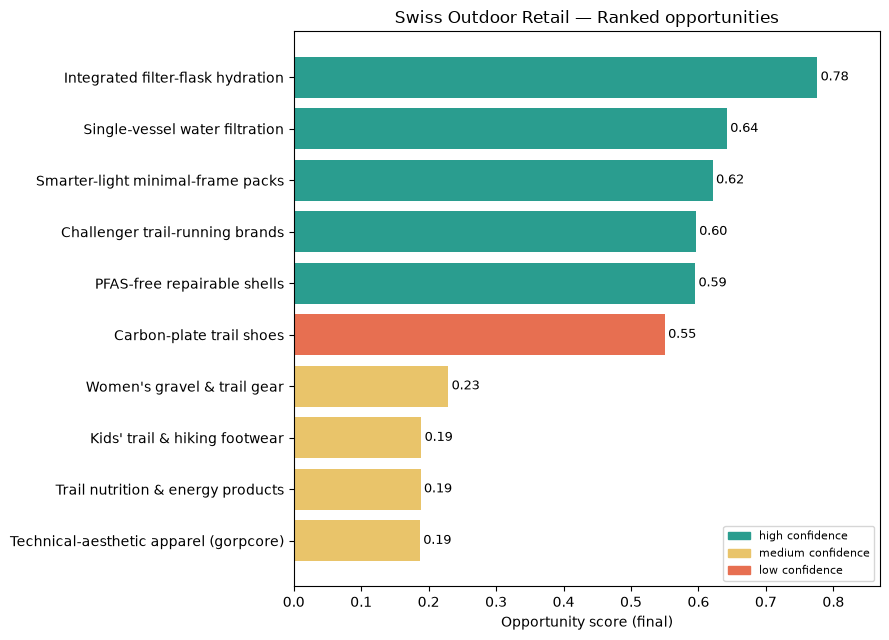

In [3]:
report.plot_ranked(opps, scn); plt.show()

## 3. Hero opportunity
The #1 signal-to-shelf gap, with its 5-dimension transfer profile.

### 🥇 Integrated filter-flask hydration

**Swiss transfer score:** 80/100 · **Confidence:** high · **Coverage:** absent · **Final score:** 0.78

**Why now:** CH search interest is flat while US/UK/KR accelerate (1.7x) and EU availability via Bergfreunde signals an open transfer window before competitors localize.

**Transferability:** Strong DACH fit given alpine hut-and-stream water culture, with EU stock already proving regulatory and taste compatibility.

**Recommended action:** Test-buy 2-3 SKUs (filter-in-cap soft flasks) for a focused trail-running pilot ahead of spring 2026 season.

**Risks:** Filter media lifespan and CH water-quality skepticism may dampen perceived need versus simple soft flasks.

**Evidence:**
- **community forum**: [r/Ultralight](https://reddit.com/r/Ultralight), [r/trailrunning](https://reddit.com/r/trailrunning)
- **competitor assortment**: [Bergfreunde](https://www.bergfreunde.de/filter-flask/), [REI](https://www.rei.com/search?q=filter%20flask)
- **search trends**: [Google Trends](https://trends.google.com/trends/explore?q=filter%20flask&geo=CH), [Google Trends](https://trends.google.com/trends/explore?q=filter%20flask&geo=GB), [Google Trends](https://trends.google.com/trends/explore?q=filter%20flask&geo=KR), [Google Trends](https://trends.google.com/trends/explore?q=filter%20flask&geo=US)

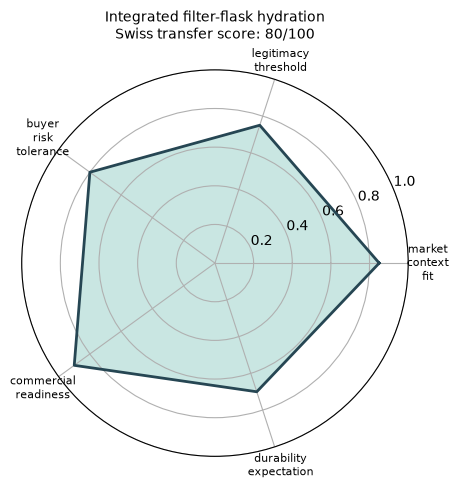

In [4]:
hero = ranked[0]
display(Markdown(report.hero_markdown(hero, scn)))
report.transfer_radar(hero, scn); plt.show()

## 4. Blank shelf — who stocks it?
Reference retailers (origin markets) vs local CH competitors. `✓` stocked · `—` absent locally (= the gap) · `·` not observed.

In [5]:
display(report.blank_shelf_table(opps, scn))

,REI (ref),Bergfreunde (ref),Transa (CH),Ochsner Sport (CH),Galaxus (CH)
opportunity,,,,,
Integrated filter-flask hydration,✓,✓,—,—,—
Single-vessel water filtration,✓,·,—,—,—
Smarter-light minimal-frame packs,✓,✓,✓,—,—
Challenger trail-running brands,✓,·,—,—,—
PFAS-free repairable shells,·,✓,✓,—,—
Carbon-plate trail shoes,✓,·,✓,✓,—


## 5. Whitespace map
Velocity (rising) vs local assortment gap. **Top-right = rising AND uncovered locally = best buys.** Bubble size = opportunity score.

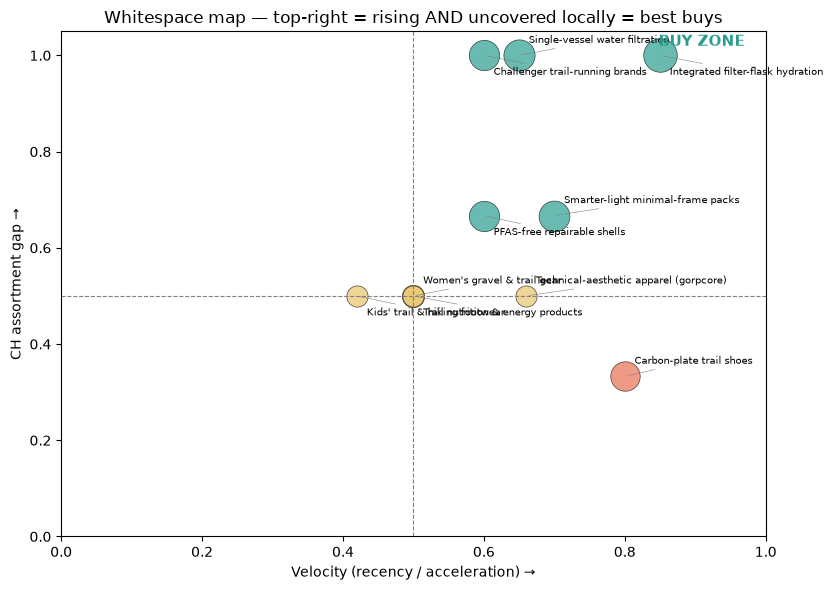

In [6]:
report.plot_whitespace(opps, scn); plt.show()

## 6. Noise graveyard
What the system **rejected**, and why — proof it has judgment, not just hype amplification.

In [7]:
display(report.graveyard_table(opps))

,why filtered out
discarded signal,
Influencer trail-apparel collab,single source type — not corroborated; transfe...
TikTok viral hydration gimmick,single source type — not corroborated; transfe...
Desert-ultra race vest,single source type — not corroborated; transfe...


## 7. Within-scenario reuse — category toggle
Change `CATEGORY` to `'day_hiking'` and re-run: same engine, different category.

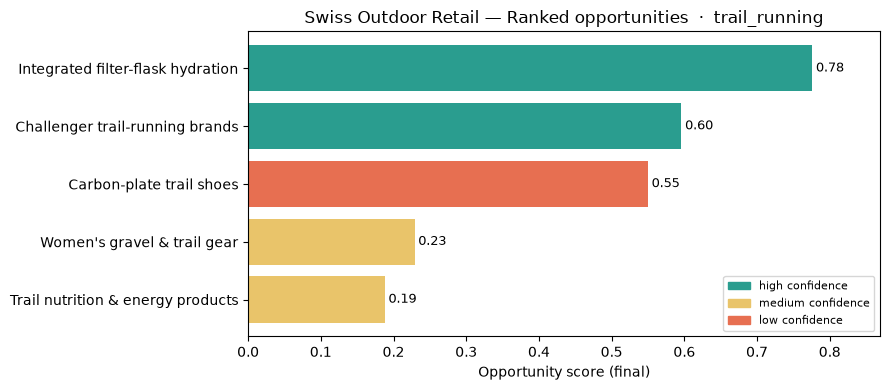

In [8]:
CATEGORY = 'trail_running'  # try 'day_hiking'
report.plot_ranked(opps, scn, category=CATEGORY); plt.show()

## 8. Cross-scenario reuse — *config, not code*
The whole product retargets to a new market/vertical by editing one YAML. Below: the live Swiss profile vs the empty template an analyst fills in.

In [9]:
from pathlib import Path
print('── swiss_outdoor.yaml (first 28 lines) ──')
print('\n'.join(Path('config/scenarios/swiss_outdoor.yaml').read_text().splitlines()[:28]))
print('\n── _template.yaml blocks an analyst fills in ──')
print('\n'.join(l for l in Path('config/scenarios/_template.yaml').read_text().splitlines() if l.strip().endswith(':') or l.startswith('# '))[:1200])

# If a second scenario has been run, show it surfaces too (cross-industry proof):
stub = Path('outputs/uk_beauty_stub/opportunities.json')
if stub.exists():
    o2, s2 = report.load_results('uk_beauty_stub')
    print(f'\nuk_beauty_stub → {len(report.live(o2))} opportunities surfaced from the SAME pipeline')
else:
    print('\n(Run: python -m src.pipeline --scenario config/scenarios/uk_beauty_stub.yaml to populate the cross-industry beat)')

── swiss_outdoor.yaml (first 28 lines) ──
scenario_id: swiss_outdoor
display_name: "Swiss Outdoor Retail"

# ─── Markets ─────────────────────────────────────────────────────────────────
target_market: CH            # where we sell
reference_markets:           # origin / early-signal markets
  - US
  - UK
  - DE
  - JP                       # Asia: major outdoor & style trend origins
  - KR                       #   (esp. for geo_style_diffusion, e.g. gorpcore)
  - CN

# ─── Local shelf reality (CH) ────────────────────────────────────────────────
local_competitors:
  - name: Transa
    url: https://www.transa.ch
    role: Premium outdoor specialist
  - name: Ochsner Sport
    url: https://www.ochsnersport.ch
    role: Mass outdoor + sport
  - name: Galaxus
    url: https://www.galaxus.ch
    role: Online breadth
    category_path: outdoor

# ─── Early commercial proof (reference retailers) ────────────────────────────
reference_retailers:

── _template.yaml blocks an analyst fills in 